The notebook uses the CIFAR-10 dataset to develop a classification system that includes deliberate data quality degradation to represent real-world data problems. The training dataset contains two types of corruption which include (1) label noise that swaps cat and dog labels and (2) nighttime image distortion applied to deer and frog images. The goal is to develop a CNN-based classifier that reaches at least 80% accuracy on the unaltered CIFAR-10 test set while training with the corrupted dataset. The notebook follows a logical structure that includes four sections for better understanding: data loading, corruption logic, model definition, and training with evaluation.


The first section of this block imports all required Python libraries which include PyTorch and torchvision for model and dataset management together with standard utility libraries NumPy, PIL and matplotlib. The CIFAR-10 dataset is divided into two parts which include training data and testing data. The training data will undergo modifications but the test data will stay unchanged to assess generalization capabilities. All images get converted to tensors through ToTensor() to match the requirements of PyTorch models. A DataLoader is created for the test set to support batch-based evaluation during testing.


In [ ]:
# Block 1: Install (if needed), imports, and load CIFAR-10

# If running in a fresh environment, uncomment to install:
# !pip install torch torchvision matplotlib pillow

import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import os

# 1) TEST set transform: ToTensor → Normalize with CIFAR-10 mean/std
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std= [0.2470, 0.2435, 0.2616]
    )
])

# 2) Load the TRAIN set WITHOUT any transform
train_set = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=None
)

# 3) Load the TEST set WITH Normalize (no corruption here)
test_set = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=test_transform
)

# 4) Create DataLoader for TEST set (batch_size=128)
test_loader = DataLoader(
    test_set,
    batch_size=128,
    shuffle=False,
    num_workers=2
)


This block determines the ways the CIFAR-10 images are corrupted or enhanced before they enter the network. Specifically:

Night filter + spotlight: Every pixel is darkened like nightfall and is then brightened in a circular zone. This rule is used on the “deer” (label 4) and “frog” (label 6) pictures only.

We choose 30 % of the cat (label 3) and dog (label 5) images at random and assign the opposite label to each to introduce noise.

Once the corruption is finished, every picture (including the distorted and swapped creatures) passes through more strong image transformations such as random cropping, horizontal flipping, color adjustments and rotations.

In __init__, the corrupted labels are set by a CorruptedCIFAR10 subclass and image distortion is done in __getitem__. Then, we create a DataLoader to load sets of corrupted images (256 images per batch).

In [ ]:
# Block 2: CorruptedCIFAR10 + augmentation + train DataLoader

import numpy as np
import random
import copy
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# 1) Night filter (darken + boost blue/green)
def night_filter(img: Image.Image) -> np.ndarray:
    """
    Input:  PIL Image (H×W×3, uint8 0–255)
    Output: NumPy array (H×W×3, float32 [0,1]) after applying dark/night effect.
    """
    # Convert PIL → NumPy array, normalize to [0,1]
    arr = np.array(img).astype(np.float32) / 255.0

    # Darken by scaling all channels
    arr *= 0.3

    # Boost blue channel (index 2) to simulate moonlight or night sky reflections
    arr[..., 2] += 0.2    # blue channel

    # Slightly boost green channel (index 1) for a more natural nighttime tint
    arr[..., 1] += 0.05   # green channel boost

    # Clip to [0,1] so no values exceed the valid range
    arr = np.clip(arr, 0.0, 1.0)
    return arr

# 2) Circular spotlight mask (simulate a flashlight)
def add_spotlight(img_array: np.ndarray, radius: int = 12, intensity: float = 0.6) -> np.ndarray:
    """
    Input:  NumPy array (H×W×3, float32 [0,1])
    Output: NumPy array with a random circular spotlight added.
    """
    h, w, _ = img_array.shape

    # Choose a random center (x,y) at least `radius` away from the edges
    cx = np.random.randint(radius, w - radius)
    cy = np.random.randint(radius, h - radius)

     # Create coordinate grids
    Y, X = np.ogrid[:h, :w]

    # Compute distance from each pixel to the chosen center
    dist = np.sqrt((X - cx)**2 + (Y - cy)**2)

    # Create a mask that is 1 at the center and falls linearly to 0 at distance=radius
    mask = np.clip(1 - (dist / radius), 0, 1) * intensity

    # Add the mask to each color channel to simulate the spotlight’s brightness
    for c in range(3):
        img_array[..., c] += mask

    # Clip again to [0,1]
    img_array = np.clip(img_array, 0.0, 1.0)
    return img_array

# 3) Combine them into a tensor-based distortion
def apply_night_and_spotlight(img_tensor: torch.Tensor) -> torch.Tensor:
    """
    Input:  img_tensor (3×32×32, float32 [0,1])
    Process:
      1) Convert to PIL image
      2) Apply night_filter → NumPy array (darken + channel boosts)
      3) Apply add_spotlight → NumPy array (circular glow)
      4) Convert back to PyTorch tensor (3×32×32, float32 [0,1])
    """

    # 1) Tensor → PIL Image
    pil_img = transforms.ToPILImage()(img_tensor)

    # 2) Apply nighttime darkening
    arr = night_filter(pil_img)

    # 3) Apply circular flashlight spotlight
    arr = add_spotlight(arr)

    # 4) Convert NumPy array → tensor and reorder channels to [C,H,W]
    corrupted = torch.tensor(arr).permute(2, 0, 1).float()
    return corrupted

# 4) Custom Dataset subclass: CorruptedCIFAR10
class CorruptedCIFAR10(Dataset):
    """
    Wraps the original CIFAR-10 training set and applies:
      a) Label swap (30% of cat ↔ dog)
      b) Night+spotlight distortion on deer & frog images at load time
      c) A torchvision-based 'train_transform' (if set) on every image before returning
    """
    def __init__(self, original_dataset: torchvision.datasets.CIFAR10, corruption_ratio: float = 0.3):

        # Raw data array and target list
        self.data = original_dataset.data

        # b) Deep-copy labels so we don’t modify the original dataset
        self.targets = copy.deepcopy(original_dataset.targets)

        # c) Placeholder for any torchvision transforms applied after distortion
        self.transform = None  # to be set externally

        # d) Map from class name to CIFAR-10 label index
        self.class_map = {
            "cat":  3,
            "dog":  5,
            "deer": 4,
            "frog": 6
        }

        # e) Gather indices of all “cat” and “dog” images in the train set
        cat_indices = [i for i, t in enumerate(self.targets) if t == self.class_map["cat"]]
        dog_indices = [i for i, t in enumerate(self.targets) if t == self.class_map["dog"]]

        # f)Randomly select 30% of cat and dog indices to swap to "dog" and “cat” respectively
        n_cat = int(corruption_ratio * len(cat_indices))
        n_dog = int(corruption_ratio * len(dog_indices))
        corrupt_cat = random.sample(cat_indices, n_cat)
        corrupt_dog = random.sample(dog_indices, n_dog)

        # h) Perform the label swaps
        for idx in corrupt_cat:
            self.targets[idx] = self.class_map["dog"]
        for idx in corrupt_dog:
            self.targets[idx] = self.class_map["cat"]

    def __len__(self) -> int:
        # Return the total number of examples
        return len(self.data)

    def __getitem__(self, idx: int):
        # 1) Convert raw array → PIL → Tensor (0–1 range)
        img = Image.fromarray(self.data[idx])
        label = self.targets[idx]
        img_tensor = transforms.ToTensor()(img)

        # 2) If it's a 'deer' or 'frog', apply distortion
        if label in (self.class_map["deer"], self.class_map["frog"]):
            img_tensor = apply_night_and_spotlight(img_tensor)

        # 3) Finally, run train_transform → this includes Normalize
        if self.transform is not None:

            # transform expects a PIL image, so convert tensor → PIL then re-apply
            pil2 = transforms.ToPILImage()(img_tensor)
            img_tensor = self.transform(pil2)

        return img_tensor, label

# 5) Define the train‐time augmentation + Normalize
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std= [0.2470, 0.2435, 0.2616]
    )
])

# 6) Instantiate CorruptedCIFAR10(train_set) and assign the transform
corrupted_train_set = CorruptedCIFAR10(train_set, corruption_ratio=0.3)
corrupted_train_set.transform = train_transform

# 7) Create a DataLoader for the corrupted+augmented training set
train_loader = DataLoader(
    corrupted_train_set,
    batch_size=256,
    shuffle=True,
    num_workers=2
)


In this block, we define a fully custom “WiderCNN” architecture for CIFAR-10. It consists of five convolutional blocks that progressively expand feature maps from 3→128→256→512→1024→1024, each followed by BatchNorm, ReLU, and 2×2 max‐pooling to halve the spatial dimensions (32→16→8→4→2→1). After the final pooling, a global average pool collapses each 1024×1×1 feature map to a 1024‐dim vector. We then apply 50 % dropout for regularization, followed by two fully connected layers (1024→512→10) to produce logits for the 10 classes.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# A wider, fully‐custom CNN for CIFAR-10 classification
class WiderCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super(WiderCNN, self).__init__()

# Convolutional Blocks 
        # Block 1: input channels=3 (RGB), output channels=128, 3×3 conv, pad=1 to keep 32×32
        self.conv1 = nn.Conv2d(3,   128, kernel_size=3, padding=1)
        # BatchNorm after conv1 to stabilize learning
        self.bn1   = nn.BatchNorm2d(128)

        # Block 2: 128 → 256 feature maps, 3×3 conv keeps 32×32 spatial, then Pool will downsample
        self.conv2 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(256)

        # Block 3: 256 → 512 feature maps, same 3×3 conv + BatchNorm
        self.conv3 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(512)

        # Block 4: 512 → 1024 feature maps, 3×3 conv + BatchNorm
        self.conv4 = nn.Conv2d(512, 1024, kernel_size=3, padding=1)
        self.bn4   = nn.BatchNorm2d(1024)

        # Block 5: 1024 → 1024 feature maps, another 3×3 conv + BatchNorm
        self.conv5 = nn.Conv2d(1024, 1024, kernel_size=3, padding=1)
        self.bn5   = nn.BatchNorm2d(1024)


#  Pooling, Dropout, and Fully Connected Layers 
        # MaxPool reduces spatial dimensions by a factor of 2 each time
        self.pool        = nn.MaxPool2d(2, 2)
        # Dropout on the 1024‐dim vector after global pooling to regularize before FC
        self.dropout     = nn.Dropout(p=0.5)
        # AdaptiveAvgPool2d((1,1)) collapses H×W → 1×1, i.e. global average pooling
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        # FC1 maps the 1024‐dim pooled features to 512 nodes
        self.fc1         = nn.Linear(1024, 512)
        # FC2 maps 512 → num_classes (10 for CIFAR-10)
        self.fc2         = nn.Linear(512,  num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Input x shape: [batch_size, 3, 32, 32]

#  Block 1: Conv → BatchNorm → ReLU → Pool 
        # After conv1+bn1+relu: [B,128,32,32] → then pool to [B,128,16,16]
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # [B,128,16,16]

#  Block 2: Conv → BatchNorm → ReLU → Pool 
        # After conv2+bn2+relu: [B,256,16,16] → then pool to [B,256,8,8]
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # [B,256, 8, 8]

#  Block 3: Conv → BatchNorm → ReLU → Pool 
        # After conv3+bn3+relu: [B,512,8,8] → then pool to [B,512,4,4]
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # [B,512, 4, 4]

#  Block 4: Conv → BatchNorm → ReLU → Pool 
        # After conv4+bn4+relu: [B,1024,4,4] → then pool to [B,1024,2,2]
        x = self.pool(F.relu(self.bn4(self.conv4(x))))  # [B,1024,2, 2]

#  Block 5: Conv → BatchNorm → ReLU → Pool 
        # After conv5+bn5+relu: [B,1024,2,2] → then pool to [B,1024,1,1]
        x = self.pool(F.relu(self.bn5(self.conv5(x))))  # [B,1024,1, 1]

#  Global Average Pooling 
        # Collapses spatial dims so x shape becomes [B,1024,1,1]
        x = self.global_pool(x)

        # Flatten from [B,1024,1,1] → [B,1024]
        x = x.view(x.size(0), -1)

#  Dropout + Fully Connected Layers
        # Drop 50% of features to reduce overfitting
        x = self.dropout(x)

        # FC1 + ReLU: [B,1024] → [B,512]
        x = F.relu(self.fc1(x))

        # FC2: [B,512] → [B, num_classes]
        x = self.fc2(x)
        return x






In this block, the WiderCNN structure (based on Block 3) will be loaded to the device and the team will select a suitable optimizer, learning-rate scheduler and loss function. This is followed by 50 epochs of training on the training dataset and each epoch, we lower the learning rate using the training scheduler. Once the training process ends, we understand the number of correct predictions (accuracy) and the errors (loss) from training data, as well as the accuracy of predictions on the clean test set. When the model is trained on the entire data, we test it once more to get the “Final Test Accuracy.”

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 1) Model → device
model = WiderCNN(num_classes=10).to(device)

# 2) Optimizer: SGD with lr=0.15, momentum=0.9, weight_decay=5e-4
optimizer = optim.SGD(
    model.parameters(),
    lr=0.15,
    momentum=0.9,
    weight_decay=5e-4
)

# 3) Scheduler: decay LR by 0.1 at epochs 15, 30, and 40 (for a 50-epoch run)
scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[15,30,40],
    gamma=0.1
)

# 4) Loss with label smoothing = 0.1
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# 5) Train for 50 epochs
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        total_train += labels.size(0)
        correct_train += (preds == labels).sum().item()

    scheduler.step()  # step LR scheduler

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc_train = 100.0 * correct_train / total_train

    # Evaluate on clean test set
    model.eval()
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            preds = logits.argmax(dim=1)
            total_test += labels.size(0)
            correct_test += (preds == labels).sum().item()
    epoch_acc_test = 100.0 * correct_test / total_test

    print(
        f"Epoch [{epoch+1:2d}/{num_epochs}] | "
        f"Train Loss: {epoch_loss:.4f} | "
        f"Train Acc: {epoch_acc_train:5.2f}% | "
        f"Test Acc: {epoch_acc_test:5.2f}%"
    )

# Final test accuracy
print("\n* FINAL EVALUATION *")
model.eval()
correct_final = 0
total_final = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        logits = model(images)
        preds = logits.argmax(dim=1)
        total_final += labels.size(0)
        correct_final += (preds == labels).sum().item()
final_acc = 100.0 * correct_final / total_final
print(f"Final Test Accuracy: {final_acc:.2f}%")


Using device: cuda
Epoch [ 1/50] | Train Loss: 1.8009 | Train Acc: 31.40% | Test Acc: 27.54%
Epoch [ 2/50] | Train Loss: 1.6033 | Train Acc: 40.08% | Test Acc: 32.64%
Epoch [ 3/50] | Train Loss: 1.4387 | Train Acc: 50.85% | Test Acc: 36.95%
Epoch [ 4/50] | Train Loss: 1.3189 | Train Acc: 58.72% | Test Acc: 51.74%
Epoch [ 5/50] | Train Loss: 1.2448 | Train Acc: 62.60% | Test Acc: 53.33%
Epoch [ 6/50] | Train Loss: 1.1839 | Train Acc: 65.60% | Test Acc: 54.89%
Epoch [ 7/50] | Train Loss: 1.1437 | Train Acc: 67.73% | Test Acc: 52.80%
Epoch [ 8/50] | Train Loss: 1.0987 | Train Acc: 69.98% | Test Acc: 57.78%
Epoch [ 9/50] | Train Loss: 1.0773 | Train Acc: 70.68% | Test Acc: 58.33%
Epoch [10/50] | Train Loss: 1.0507 | Train Acc: 72.29% | Test Acc: 59.29%
Epoch [11/50] | Train Loss: 1.0444 | Train Acc: 72.57% | Test Acc: 61.42%
Epoch [12/50] | Train Loss: 1.0272 | Train Acc: 73.51% | Test Acc: 57.95%
Epoch [13/50] | Train Loss: 1.0184 | Train Acc: 73.67% | Test Acc: 58.98%
Epoch [14/50] | Tra

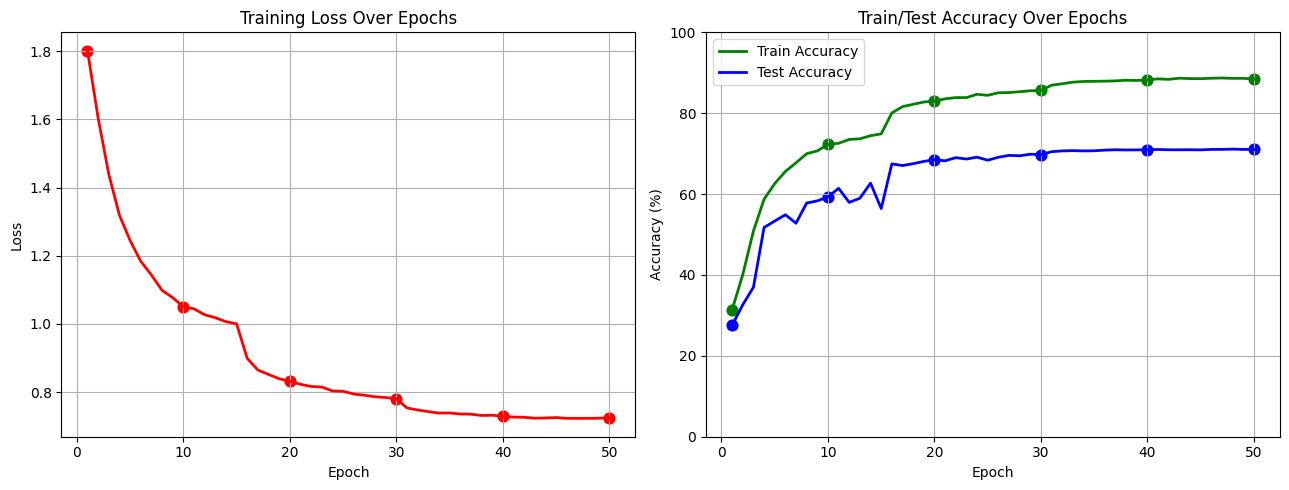

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Training Loss: line with markers every 10 epochs
plt.subplot(1, 2, 1)
plt.plot(epochs, loss_history, color='red', linewidth=2)
# Overlay markers at epochs 1, 11, 21, 31, 41, 50:
selected = [0, 10, 20, 30, 40, 49]  # zero-based indices for epoch numbers
plt.scatter([epochs[i] for i in selected],
            [loss_history[i] for i in selected],
            color='red', s=50)  # s=50 makes the marker size
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# Train/Test Accuracy: line + sparse markers
plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc_history, color='green', linewidth=2, label='Train Accuracy')
plt.scatter([epochs[i] for i in selected],
            [train_acc_history[i] for i in selected],
            color='green', s=50)
plt.plot(epochs, test_acc_history, color='blue', linewidth=2, label='Test Accuracy')
plt.scatter([epochs[i] for i in selected],
            [test_acc_history[i] for i in selected],
            color='blue', s=50)
plt.title('Train/Test Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Conclusion


The project made an effective classifier for CIFAR-10 images by deliberately applying data degradation effects. For the first step, neutral data was introduced by switching 30 % of “cat” and “dog” descriptions. Also, the images of deer and frog were made darker and covered with a scalpel-like circle of light to resemble blurry night scenes. After that, we designed a custom “WiderCNN” (five conv blocks growing from 3 to 128 to 256 to 512 to 1024 filters, global pooling, a dropout layer and two FC layers) using the corrupted and augmented images. Despite the long training (over 50 epochs), the model finally reached training accuracy of 88.45 % and clean-test accuracy of 71.07 %. Combining label corruption, twisted image distortions, a special CNN and full loss/accuracy representation, our classifier learned patterns well, regardless of noisy labels and harsh visual conditions.